# Weather Classification using ANNs


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
data=pd.read_csv(r'datasets\weather_classification_data.csv')
data

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy
...,...,...,...,...,...,...,...,...,...,...,...
13195,10.0,74,14.5,71.0,overcast,1003.15,1,Summer,1.0,mountain,Rainy
13196,-1.0,76,3.5,23.0,cloudy,1067.23,1,Winter,6.0,coastal,Snowy
13197,30.0,77,5.5,28.0,overcast,1012.69,3,Autumn,9.0,coastal,Cloudy
13198,3.0,76,10.0,94.0,overcast,984.27,0,Winter,2.0,inland,Snowy


In [4]:
data.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


#  Data Preprocessing

In [5]:
data.describe()

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km)
count,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000
mean,19.127576,68.710833,9.832197,53.644394,1005.827896,4.005758,5.462917
std,17.386327,20.194248,6.908704,31.946541,37.199589,3.856600,3.371499
min,-25.000000,20.000000,0.000000,0.000000,800.120000,0.000000,0.000000
25%,4.000000,57.000000,5.000000,19.000000,994.800000,1.000000,3.000000
50%,21.000000,70.000000,9.000000,58.000000,1007.650000,3.000000,5.000000
75%,31.000000,84.000000,13.500000,82.000000,1016.772500,7.000000,7.500000
max,109.000000,109.000000,48.500000,109.000000,1199.210000,14.000000,20.000000


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB


In [7]:
data.dtypes

Temperature             float64
Humidity                  int64
Wind Speed              float64
Precipitation (%)       float64
Cloud Cover              object
Atmospheric Pressure    float64
UV Index                  int64
Season                   object
Visibility (km)         float64
Location                 object
Weather Type             object
dtype: object

In [8]:
data.columns

Index(['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)',
       'Cloud Cover', 'Atmospheric Pressure', 'UV Index', 'Season',
       'Visibility (km)', 'Location', 'Weather Type'],
      dtype='object')

In [9]:
df=data.copy()

In [10]:
X=df.drop(['Weather Type'],axis=1)
y=df['Weather Type']


In [11]:
X

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain
...,...,...,...,...,...,...,...,...,...,...
13195,10.0,74,14.5,71.0,overcast,1003.15,1,Summer,1.0,mountain
13196,-1.0,76,3.5,23.0,cloudy,1067.23,1,Winter,6.0,coastal
13197,30.0,77,5.5,28.0,overcast,1012.69,3,Autumn,9.0,coastal
13198,3.0,76,10.0,94.0,overcast,984.27,0,Winter,2.0,inland


In [12]:
y

0         Rainy
1        Cloudy
2         Sunny
3         Sunny
4         Rainy
          ...  
13195     Rainy
13196     Snowy
13197    Cloudy
13198     Snowy
13199     Rainy
Name: Weather Type, Length: 13200, dtype: object

In [13]:
numeric=X.select_dtypes(['number'])
numeric

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km)
0,14.0,73,9.5,82.0,1010.82,2,3.5
1,39.0,96,8.5,71.0,1011.43,7,10.0
2,30.0,64,7.0,16.0,1018.72,5,5.5
3,38.0,83,1.5,82.0,1026.25,7,1.0
4,27.0,74,17.0,66.0,990.67,1,2.5
...,...,...,...,...,...,...,...
13195,10.0,74,14.5,71.0,1003.15,1,1.0
13196,-1.0,76,3.5,23.0,1067.23,1,6.0
13197,30.0,77,5.5,28.0,1012.69,3,9.0
13198,3.0,76,10.0,94.0,984.27,0,2.0


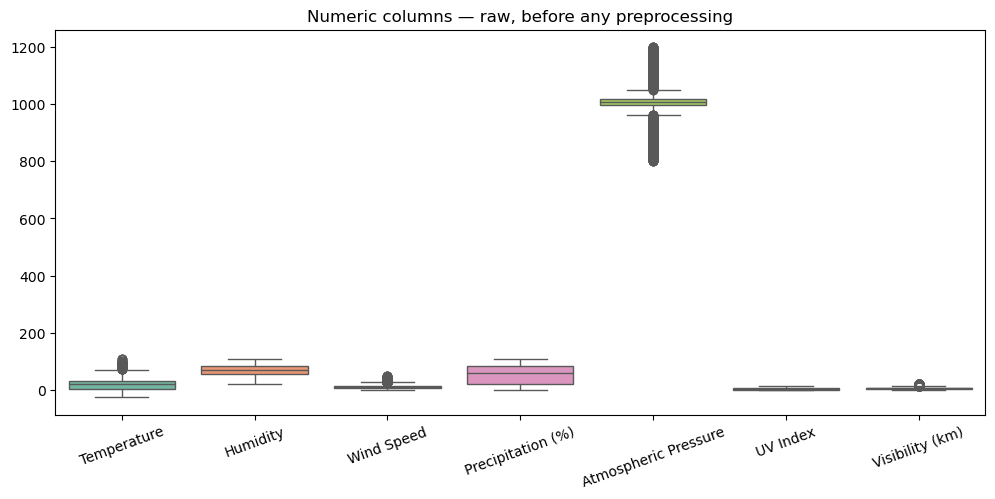

In [14]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=numeric, palette="Set2")
plt.title("Numeric columns — raw, before any preprocessing")
plt.xticks(rotation=20)
plt.show()

In [15]:
Q1 = numeric.quantile(0.25)
Q3 = numeric.quantile(0.75)
IQR = Q3 - Q1

outlier_counts = ((numeric < (Q1 - 1.5 * IQR)) | (numeric > (Q3 + 1.5 * IQR))).sum()
print(outlier_counts)

Temperature              92
Humidity                  0
Wind Speed              404
Precipitation (%)         0
Atmospheric Pressure    927
UV Index                  0
Visibility (km)         383
dtype: int64


In [16]:
print(data[data['Humidity'] > 100])

       Temperature  Humidity  Wind Speed  Precipitation (%)    Cloud Cover  \
19            13.0       102        12.0               72.0          clear   
37             2.0       105        19.0              109.0       overcast   
155           15.0       105         7.5               75.0       overcast   
239           29.0       107         0.5               93.0  partly cloudy   
247           28.0       108         7.5               83.0  partly cloudy   
...            ...       ...         ...                ...            ...   
13050        -15.0       105         3.0              103.0       overcast   
13066          5.0       102        31.0              108.0  partly cloudy   
13113         42.0       106        32.5              103.0  partly cloudy   
13124         46.0       101        16.0               80.0  partly cloudy   
13185         37.0       106        23.5              104.0  partly cloudy   

       Atmospheric Pressure  UV Index  Season  Visibility (km) 

In [17]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
numeric_scaled = scaler.fit_transform(numeric)

print(type(numeric_scaled))
print(numeric_scaled.shape)

<class 'numpy.ndarray'>
(13200, 7)


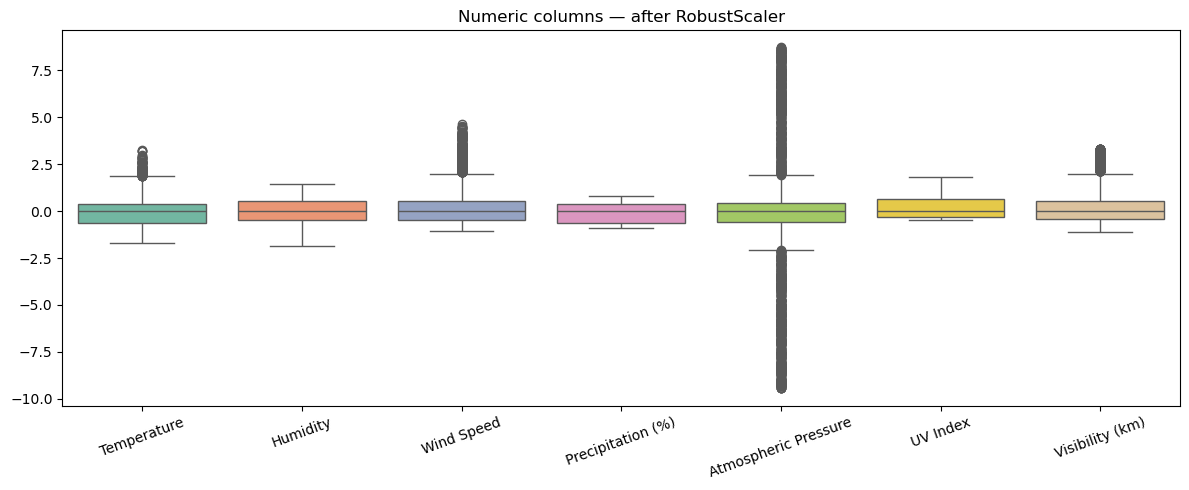

In [18]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=numeric_scaled, palette="Set2")
plt.xticks(ticks=range(len(numeric.columns)), labels=numeric.columns, rotation=20)
plt.title("Numeric columns — after RobustScaler")
plt.tight_layout()
plt.show()

In [19]:
# save column names BEFORE scaling
numeric_cols = numeric.columns

# rebuild as DataFrame AFTER scaling
numeric_scaled_df = pd.DataFrame(numeric_scaled, columns=numeric_cols)

print(type(numeric_scaled_df))
print(numeric_scaled_df.head())

<class 'pandas.core.frame.DataFrame'>
   Temperature  Humidity  Wind Speed  Precipitation (%)  Atmospheric Pressure  \
0    -0.259259  0.111111    0.058824           0.380952              0.144271   
1     0.666667  0.962963   -0.058824           0.206349              0.172033   
2     0.333333 -0.222222   -0.235294          -0.666667              0.503812   
3     0.629630  0.481481   -0.882353           0.380952              0.846513   
4     0.222222  0.148148    0.941176           0.126984             -0.772784   

   UV Index  Visibility (km)  
0 -0.166667        -0.333333  
1  0.666667         1.111111  
2  0.333333         0.111111  
3  0.666667        -0.888889  
4 -0.333333        -0.555556  


# Encoding the Categorical variables

In [20]:
categorical=X.select_dtypes('object')
categorical

,Cloud Cover,Season,Location
0,partly cloudy,Winter,inland
1,partly cloudy,Spring,inland
2,clear,Spring,mountain
3,clear,Spring,coastal
4,overcast,Winter,mountain
...,...,...,...
13195,overcast,Summer,mountain
13196,cloudy,Winter,coastal
13197,overcast,Autumn,coastal
13198,overcast,Winter,inland


In [21]:
categorical.nunique()

Cloud Cover    4
Season         4
Location       3
dtype: int64

In [22]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False)
categorical_encoded = ohe.fit_transform(categorical)

print(categorical_encoded.shape)
print()
print(ohe.get_feature_names_out())

(13200, 11)

['Cloud Cover_clear' 'Cloud Cover_cloudy' 'Cloud Cover_overcast'
 'Cloud Cover_partly cloudy' 'Season_Autumn' 'Season_Spring'
 'Season_Summer' 'Season_Winter' 'Location_coastal' 'Location_inland'
 'Location_mountain']


In [23]:
categorical_encoded 

array([[0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 1., ..., 1., 0., 0.],
       [0., 0., 1., ..., 0., 1., 0.],
       [0., 0., 1., ..., 0., 0., 1.]])

In [24]:
ohe_sparse = OneHotEncoder()
categorical_sparse = ohe_sparse.fit_transform(categorical)
print(type(categorical_sparse))
print(categorical_sparse)

<class 'scipy.sparse._csr.csr_matrix'>
  (0, 3)	1.0
  (0, 7)	1.0
  (0, 9)	1.0
  (1, 3)	1.0
  (1, 5)	1.0
  (1, 9)	1.0
  (2, 0)	1.0
  (2, 5)	1.0
  (2, 10)	1.0
  (3, 0)	1.0
  (3, 5)	1.0
  (3, 8)	1.0
  (4, 2)	1.0
  (4, 7)	1.0
  (4, 10)	1.0
  (5, 2)	1.0
  (5, 6)	1.0
  (5, 9)	1.0
  (6, 2)	1.0
  (6, 7)	1.0
  (6, 9)	1.0
  (7, 3)	1.0
  (7, 7)	1.0
  (7, 9)	1.0
  (8, 2)	1.0
  :	:
  (13191, 9)	1.0
  (13192, 0)	1.0
  (13192, 6)	1.0
  (13192, 9)	1.0
  (13193, 2)	1.0
  (13193, 7)	1.0
  (13193, 9)	1.0
  (13194, 2)	1.0
  (13194, 5)	1.0
  (13194, 8)	1.0
  (13195, 2)	1.0
  (13195, 6)	1.0
  (13195, 10)	1.0
  (13196, 1)	1.0
  (13196, 7)	1.0
  (13196, 8)	1.0
  (13197, 2)	1.0
  (13197, 4)	1.0
  (13197, 8)	1.0
  (13198, 2)	1.0
  (13198, 7)	1.0
  (13198, 9)	1.0
  (13199, 2)	1.0
  (13199, 4)	1.0
  (13199, 10)	1.0


In [25]:
# if we ever want to convert sparse to dense

# categorical_sparse_dense = categorical_sparse.toarray()

In [26]:
categorical_encoded_df = pd.DataFrame(
    categorical_encoded,
    columns=ohe.get_feature_names_out()
)

print(type(categorical_encoded_df))
print(categorical_encoded_df.shape)
print(categorical_encoded_df.head())

<class 'pandas.core.frame.DataFrame'>
(13200, 11)
   Cloud Cover_clear  Cloud Cover_cloudy  Cloud Cover_overcast  \
0                0.0                 0.0                   0.0   
1                0.0                 0.0                   0.0   
2                1.0                 0.0                   0.0   
3                1.0                 0.0                   0.0   
4                0.0                 0.0                   1.0   

   Cloud Cover_partly cloudy  Season_Autumn  Season_Spring  Season_Summer  \
0                        1.0            0.0            0.0            0.0   
1                        1.0            0.0            1.0            0.0   
2                        0.0            0.0            1.0            0.0   
3                        0.0            0.0            1.0            0.0   
4                        0.0            0.0            0.0            0.0   

   Season_Winter  Location_coastal  Location_inland  Location_mountain  
0            1.0 

In [27]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)
print(le.classes_)
print(y[:10])

['Cloudy' 'Rainy' 'Snowy' 'Sunny']
[1 0 3 3 1 0 2 2 2 3]


In [28]:
import numpy as np

# combine numeric and categorical side by side
X = pd.concat([numeric_scaled_df, categorical_encoded_df], axis=1)

print(X.shape)
print(X.head())

(13200, 18)
   Temperature  Humidity  Wind Speed  Precipitation (%)  Atmospheric Pressure  \
0    -0.259259  0.111111    0.058824           0.380952              0.144271   
1     0.666667  0.962963   -0.058824           0.206349              0.172033   
2     0.333333 -0.222222   -0.235294          -0.666667              0.503812   
3     0.629630  0.481481   -0.882353           0.380952              0.846513   
4     0.222222  0.148148    0.941176           0.126984             -0.772784   

   UV Index  Visibility (km)  Cloud Cover_clear  Cloud Cover_cloudy  \
0 -0.166667        -0.333333                0.0                 0.0   
1  0.666667         1.111111                0.0                 0.0   
2  0.333333         0.111111                1.0                 0.0   
3  0.666667        -0.888889                1.0                 0.0   
4 -0.333333        -0.555556                0.0                 0.0   

   Cloud Cover_overcast  Cloud Cover_partly cloudy  Season_Autumn  \
0    

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (10560, 18)
X_test: (2640, 18)
y_train: (10560,)
y_test: (2640,)


In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers  import Dense

c:\Users\Admin\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [34]:
# Model Define
model=Sequential([
    Dense(36, activation='relu', input_shape=(18,)),  # First hidden layer
    Dense(24, activation='relu'),                     # Second hidden layer
    Dense(4, activation='softmax')                    # Output layer
])

c:\Users\Admin\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
# Compile the model
model.compile(
    optimizer='adamW',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [37]:
model.fit(X_train,y_train,epochs=50,batch_size=20,validation_split=0.2)

Epoch 1/50
423/423 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8099 - loss: 0.6277 - val_accuracy: 0.8864 - val_loss: 0.3735
Epoch 2/50
423/423 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8933 - loss: 0.3315 - val_accuracy: 0.9067 - val_loss: 0.2985
Epoch 3/50
423/423 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9010 - loss: 0.2783 - val_accuracy: 0.9143 - val_loss: 0.2639
Epoch 4/50
423/423 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9065 - loss: 0.2536 - val_accuracy: 0.9100 - val_loss: 0.2498
Epoch 5/50
423/423 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9074 - loss: 0.2389 - val_accuracy: 0.9100 - val_loss: 0.2384
Epoch 6/50
423/423 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9100 - loss: 0.2265 - val_accuracy: 0.9100 - val_loss: 0.2311
Epoch 7/50
423/423 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9102 - loss: 0.2196 - val_accuracy: 0.9119 - val_loss: 0.2250
Epoch 8/50
423/423 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9147 - loss: 0.2111 - val_accuracy: 0.

In [38]:
predictions=model.predict(X_test)
predictions


83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


array([[1.3672548e-12, 2.2902817e-14, 1.1398240e-09, 1.0000000e+00],
       [3.7264379e-11, 2.9764015e-12, 5.2037047e-10, 1.0000000e+00],
       [6.6913039e-05, 3.2335993e-05, 1.0395251e-03, 9.9886119e-01],
       ...,
       [2.0707694e-06, 1.1411239e-05, 9.9998176e-01, 4.8386009e-06],
       [1.6689384e-06, 1.0640746e-05, 9.9996376e-01, 2.3880430e-05],
       [9.9993467e-01, 6.3836225e-05, 4.5187669e-08, 1.4563885e-06]],
      dtype=float32)

In [39]:
import numpy as np

predicted_classes = np.argmax(predictions, axis=1)
predicted_classes

array([3, 3, 3, ..., 2, 2, 0], dtype=int64)

In [40]:
for i in range(10):  # show first 10 samples
    print(f"Actual: {y_test[i]}, Predicted: {predicted_classes[i]}")

Actual: 3, Predicted: 3
Actual: 3, Predicted: 3
Actual: 3, Predicted: 3
Actual: 2, Predicted: 2
Actual: 3, Predicted: 3
Actual: 2, Predicted: 2
Actual: 3, Predicted: 3
Actual: 1, Predicted: 1
Actual: 3, Predicted: 1
Actual: 2, Predicted: 2


In [41]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")
print(f'Test Loss: {loss:.4f}')

83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9117 - loss: 0.2362
Test Accuracy: 0.9117
Test Loss: 0.2362


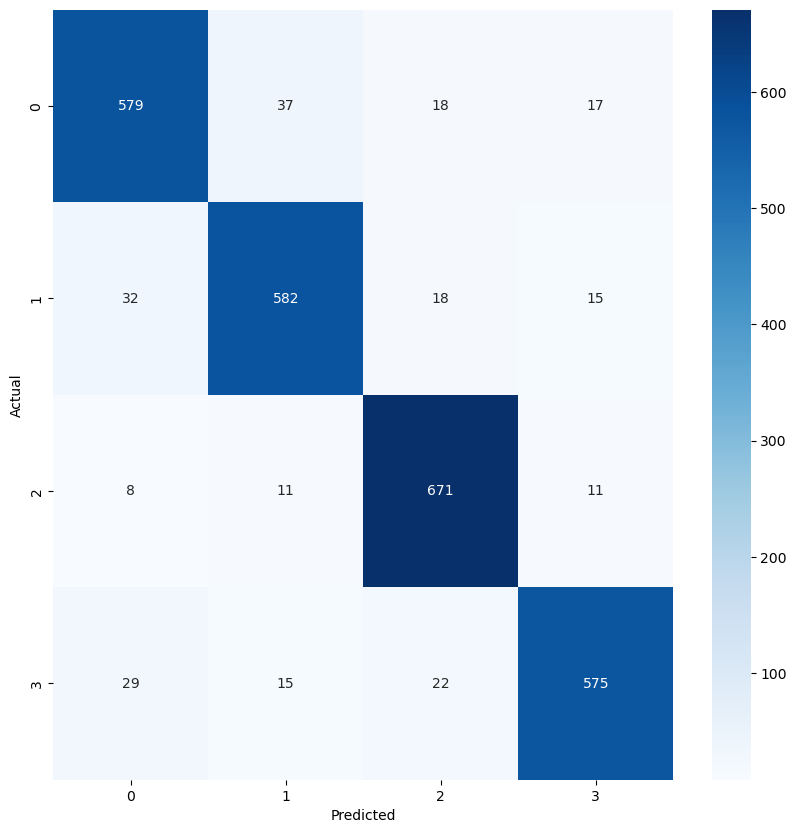

In [42]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predicted_classes)

plt.figure(figsize=(10,10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Saving the Model so that I dont have to train it again and again

In [43]:
import joblib

# Save the Keras model
model.save("weather_model.keras")

# Save all 3 preprocessors
joblib.dump(scaler, "scaler.pkl")       # RobustScaler
joblib.dump(ohe, "ohe.pkl")             # OneHotEncoder
joblib.dump(le, "le.pkl")               # LabelEncoder

print("✅ Model and all preprocessors saved!")

✅ Model and all preprocessors saved!


In [44]:
from tensorflow.keras.models import load_model

# Load everything back
model_loaded   = load_model("weather_model.keras")
scaler_loaded  = joblib.load("scaler.pkl")
ohe_loaded     = joblib.load("ohe.pkl")
le_loaded      = joblib.load("le.pkl")

print("✅ All files loaded successfully!")
print("Class labels:", le_loaded.classes_)
# Output should be: ['Cloudy' 'Rainy' 'Snowy' 'Sunny'] (or similar)

✅ All files loaded successfully!
Class labels: ['Cloudy' 'Rainy' 'Snowy' 'Sunny']
